<a href="https://colab.research.google.com/github/2FAST4Uh/Machine-Learning/blob/main/used_car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Used Car Price Prediction Analysis
Presented to you by
1. Akash Yadav        (Regression Modelling)
2. Rohan Deshwal      (Data preperation and visualisation)
3. Yanis Hasan Khan   (Classification Modelling and evaluation)



## 1. Import Libraries and Upload Dataset

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset loaded successfully")
df.head()

Saving used_cars.csv to used_cars.csv
Dataset loaded successfully


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## 2. Basic Dataset Inspection

In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)
print("\nData Types:")
df.info()

Shape: (4009, 12)

Columns:
Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price'],
      dtype='object')

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


## 3. Preview Records

In [ ]:
df.head()
df.tail()
df.sample(5)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
942,BMW,650 i,2009,"35,000 mi.",Gasoline,360.0HP 4.8L 8 Cylinder Engine Gasoline Fuel,A/T,Black,Black,None reported,Yes,"$18,500"
313,Land,Rover Discovery Sport SE R-Dynamic,2020,"20,927 mi.",Gasoline,2.0 Liter,Automatic,Fuji White,–,None reported,NaN,"$35,998"
2011,Ford,Mustang V6,2016,"54,000 mi.",Gasoline,300.0HP 3.7L V6 Cylinder Engine Gasoline Fuel,6-Speed A/T,White,Black,None reported,Yes,"$23,999"
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
3688,Jeep,Gladiator Overland,2020,"4,000 mi.",Gasoline,285.0HP 3.6L V6 Cylinder Engine Gasoline Fuel,8-Speed A/T,Silver,Black,None reported,Yes,"$50,000"


## 4. Statistical Summary and Missing Values

In [ ]:
print(df.describe(include='all'))
print("\nMissing values:")
print(df.isnull().sum())

       brand    model   model_year       milage fuel_type  \
count   4009     4009  4009.000000         4009      3839   
unique    57     1898          NaN         2818         7   
top     Ford  M3 Base          NaN  110,000 mi.  Gasoline   
freq     386       30          NaN           16      3309   
mean     NaN      NaN  2015.515590          NaN       NaN   
std      NaN      NaN     6.104816          NaN       NaN   
min      NaN      NaN  1974.000000          NaN       NaN   
25%      NaN      NaN  2012.000000          NaN       NaN   
50%      NaN      NaN  2017.000000          NaN       NaN   
75%      NaN      NaN  2020.000000          NaN       NaN   
max      NaN      NaN  2024.000000          NaN       NaN   

                            engine transmission ext_col int_col  \
count                         4009         4009    4009    4009   
unique                        1146           62     319     156   
top     2.0L I4 16V GDI DOHC Turbo          A/T   Black   Black   

## 5. Clean Price and Mileage Columns

In [ ]:
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df['milage'] = df['milage'].replace('[^0-9]', '', regex=True).astype(float)

df = df.drop_duplicates()
df = df.dropna()

df[['price','milage']].head()

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_3978/2252309170.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


,price,milage
0,10300.0,51000.0
1,38005.0,34742.0
3,15500.0,88900.0
6,31000.0,84000.0
7,7300.0,242000.0


## 6. Unique Category Counts

In [ ]:
for col in ['brand','fuel_type','transmission','accident']:
    print(f"\n{col.upper()} value counts:")
    print(df[col].value_counts().head(10))


BRAND value counts:
brand
Ford             341
BMW              316
Mercedes-Benz    268
Chevrolet        259
Toyota           171
Porsche          158
Audi             153
Lexus            136
Jeep             114
Land             100
Name: count, dtype: int64

FUEL_TYPE value counts:
fuel_type
Gasoline          2815
Hybrid             145
E85 Flex Fuel      128
Diesel             102
–                   44
Plug-In Hybrid      33
not supported        2
Name: count, dtype: int64

TRANSMISSION value counts:
transmission
A/T                               939
8-Speed A/T                       391
Transmission w/Dual Shift Mode    389
6-Speed A/T                       354
6-Speed M/T                       238
7-Speed A/T                       201
10-Speed A/T                      115
5-Speed A/T                        84
9-Speed A/T                        73
4-Speed A/T                        72
Name: count, dtype: int64

ACCIDENT value counts:
accident
None reported                      

## 7. Correlation Analysis

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
corr_matrix = numeric_df.corr()
corr_matrix

,model_year,milage,price
model_year,1.000000,-0.580814,0.183538
milage,-0.580814,1.000000,-0.285901
price,0.183538,-0.285901,1.000000


## 8. Correlation Heatmap

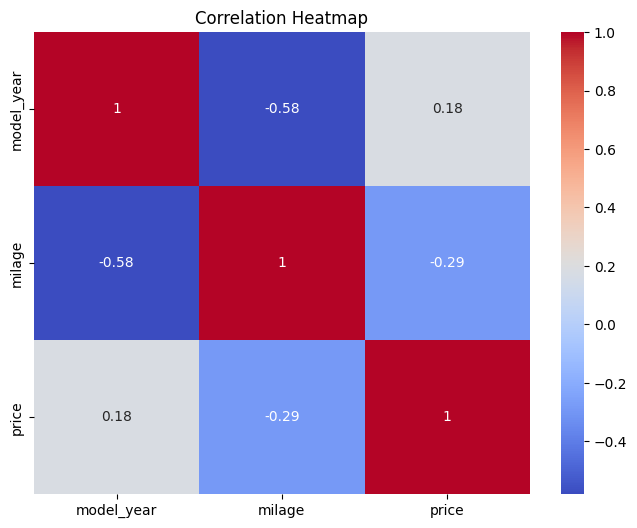

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## 9. Price Distribution

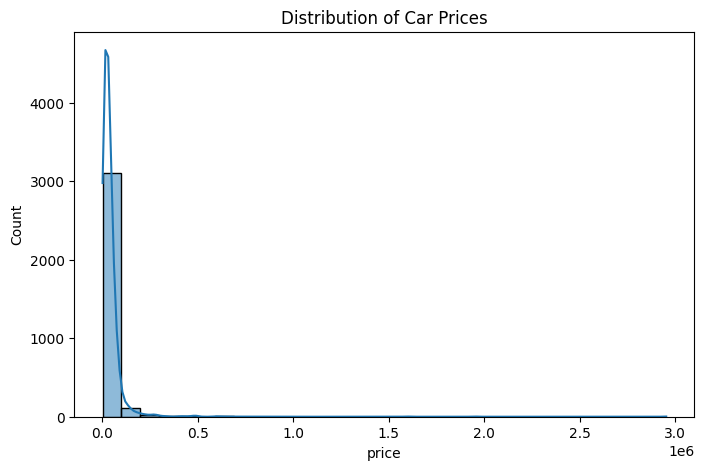

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Distribution of Car Prices")
plt.show()

## 10. Boxplot for Outlier Detection

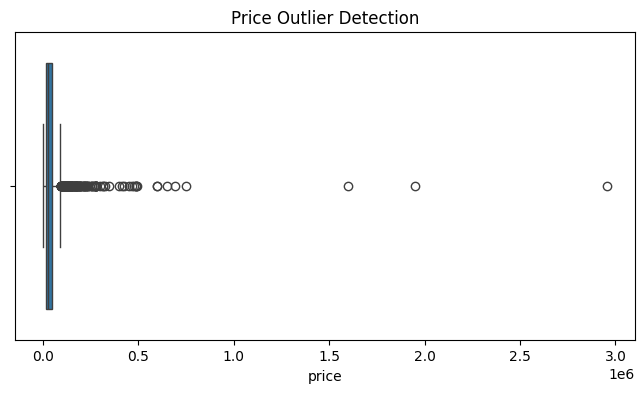

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['price'])
plt.title("Price Outlier Detection")
plt.show()

## 11. Mileage vs Price

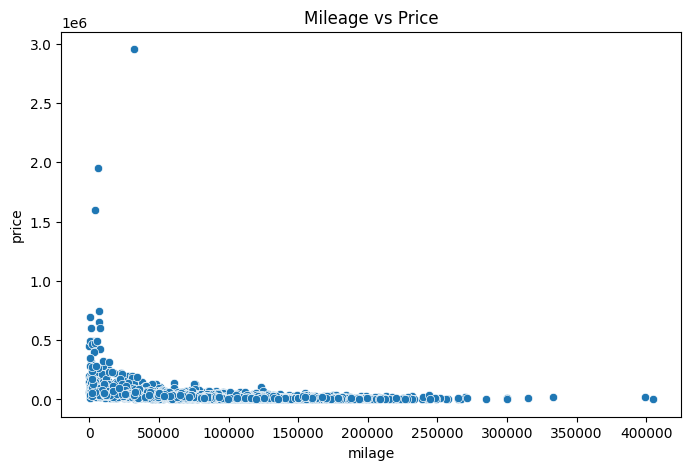

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='milage', y='price')
plt.title("Mileage vs Price")
plt.show()

## 12. Average Price by Fuel Type

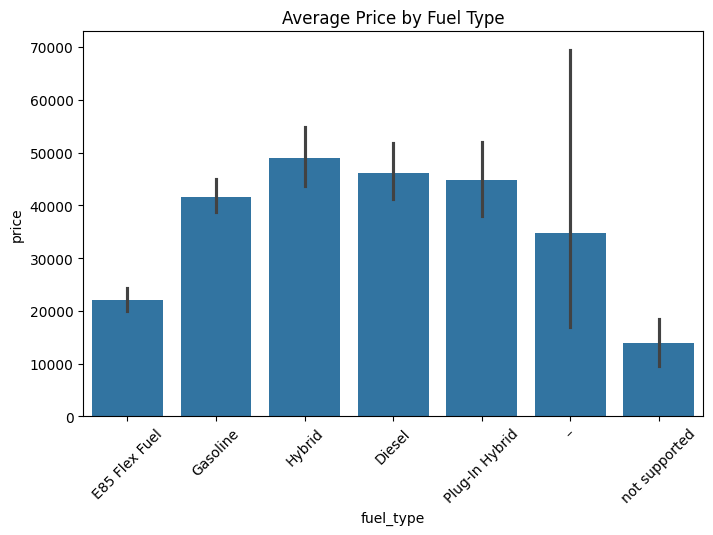

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='fuel_type', y='price')
plt.xticks(rotation=45)
plt.title("Average Price by Fuel Type")
plt.show()

## 13. Average Price by Accident History

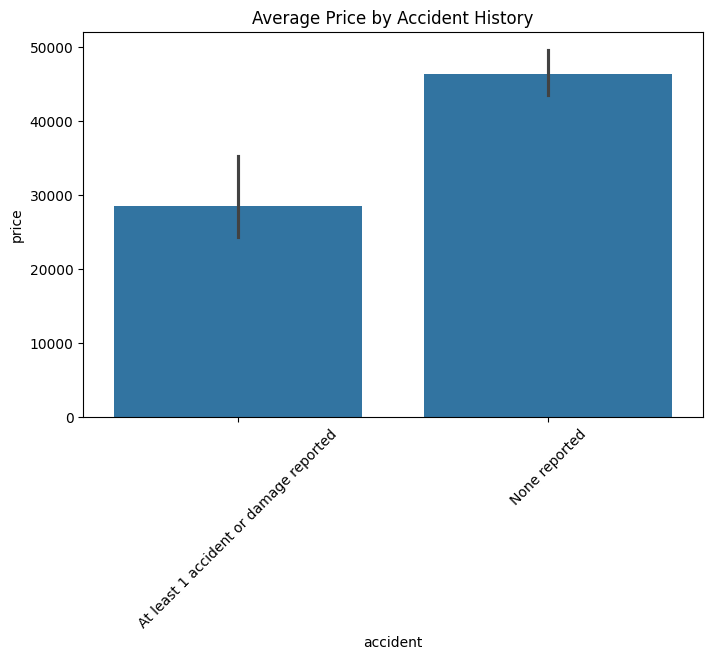

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='accident', y='price')
plt.xticks(rotation=45)
plt.title("Average Price by Accident History")
plt.show()

## 14. Encode Categorical Variables

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,14,1481,2013,51000.0,1,492,7,8,1,0,0,10300.0
1,19,1011,2021,34742.0,2,478,20,69,32,0,0,38005.0
3,20,1055,2015,88900.0,3,630,13,8,1,1,0,15500.0
6,3,1235,2017,84000.0,2,442,7,14,1,1,0,31000.0
7,4,119,2001,242000.0,2,415,24,47,33,1,0,7300.0


## 15. Prepare Features and Target

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

## 16. Train Test Split and Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 17. Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

## 18. Evaluate Regression Model

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 13933521240.36737
R2 Score: 0.04850309332022884


## 19. Actual vs Predicted Prices

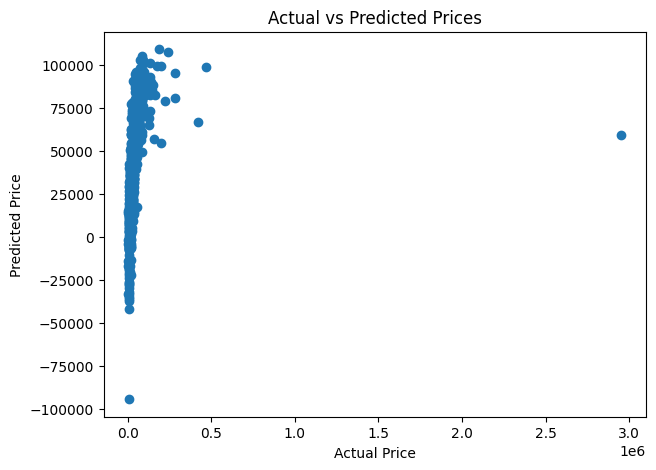

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

## 20. Regression Coefficients

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

print("Intercept:", lr.intercept_)
coefficients.sort_values(by='Coefficient', ascending=False)

Intercept: 40808.49101338428


,Feature,Coefficient
5,engine,19278.839182
0,brand,5363.750030
8,int_col,4866.819216
2,model_year,3359.593274
9,accident,2780.264570
7,ext_col,1486.784080
6,transmission,275.069723
10,clean_title,0.000000
1,model,-972.768135
4,fuel_type,-2639.623106


## 21. Sample Predictions Table


In [ ]:

predictions = pd.DataFrame({
    'Actual Price': y_test.values[:10],
    'Predicted Price': y_pred[:10]
})

predictions


,Actual Price,Predicted Price
0,28900.0,39968.955410
1,417500.0,66578.686801
2,46599.0,83297.267208
3,27900.0,74168.312671
4,49990.0,80236.656377
5,15495.0,11949.894164
6,83000.0,74041.199961
7,200000.0,54801.795333
8,2500.0,-16788.677511
9,13250.0,8271.186829


## 22. Regression Line Graph


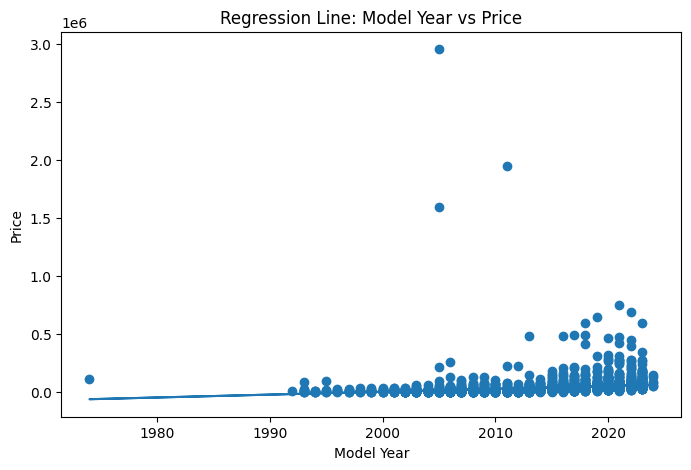

In [ ]:

single_feature_X = df[['model_year']]
single_feature_y = df['price']

simple_model = LinearRegression()
simple_model.fit(single_feature_X, single_feature_y)

plt.figure(figsize=(8,5))
plt.scatter(single_feature_X, single_feature_y)
plt.plot(single_feature_X, simple_model.predict(single_feature_X))
plt.title("Regression Line: Model Year vs Price")
plt.xlabel("Model Year")
plt.ylabel("Price")
plt.show()


## 22. Logistic Regression (High vs Low Price)

In [ ]:
median_price = df['price'].median()
df['price_category'] = (df['price'] > median_price).astype(int)

X = df.drop(['price','price_category'], axis=1)
y = df['price_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

## 23. Classification Report

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[271  43]
 [ 43 297]]
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       314
           1       0.87      0.87      0.87       340

    accuracy                           0.87       654
   macro avg       0.87      0.87      0.87       654
weighted avg       0.87      0.87      0.87       654



## 24. Sigmoid Function Visualization

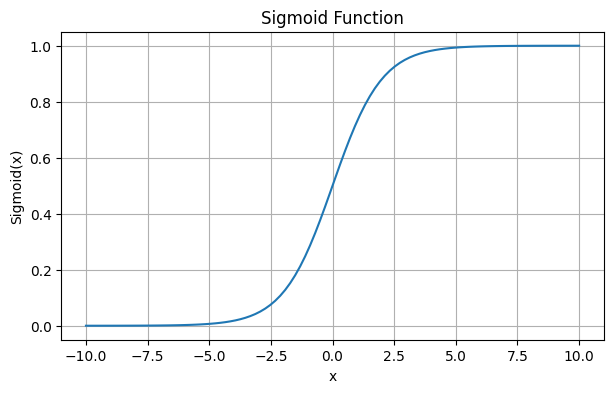

In [ ]:
x = np.linspace(-10, 10, 100)
sigmoid = 1/(1+np.exp(-x))

plt.figure(figsize=(7,4))
plt.plot(x, sigmoid)
plt.title("Sigmoid Function")
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")
plt.grid(True)
plt.show()

## 26. KNN model

In [ ]:
## KNN Classification Model
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train model
knn_model.fit(X_train, y_train)

# Predict
knn_pred = knn_model.predict(X_test)

#Evaluate KNN
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, knn_pred))

print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.8669724770642202

Confusion Matrix:
[[272  42]
 [ 45 295]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       314
           1       0.88      0.87      0.87       340

    accuracy                           0.87       654
   macro avg       0.87      0.87      0.87       654
weighted avg       0.87      0.87      0.87       654



## 27. Support Vector Machine

In [ ]:
#SVM Classification Model
from sklearn.svm import SVC

# Create SVM model
svm_model = SVC(kernel='linear')

# Train model
svm_model.fit(X_train, y_train)

# Predict
svm_pred = svm_model.predict(X_test)
# Evaluate SVM
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.8623853211009175

Confusion Matrix:
[[273  41]
 [ 49 291]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       314
           1       0.88      0.86      0.87       340

    accuracy                           0.86       654
   macro avg       0.86      0.86      0.86       654
weighted avg       0.86      0.86      0.86       654



## 28. Accuracy comparison between SVM and KNN

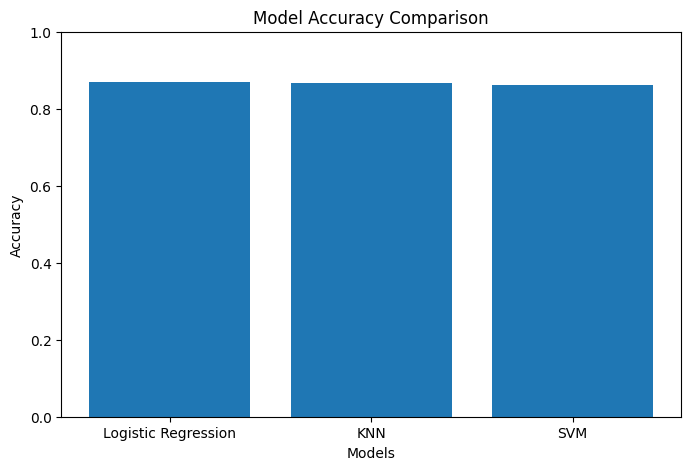

In [ ]:
models = ['Logistic Regression', 'KNN', 'SVM']
accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, knn_pred),
    accuracy_score(y_test, svm_pred)
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

## 29. Confusion Matrix heatmap for KNN

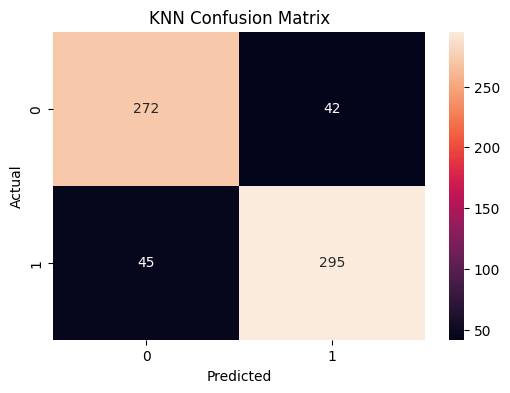

In [ ]:
import seaborn as sns

cm_knn = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 30. Confusion matrix heatmap for SVM

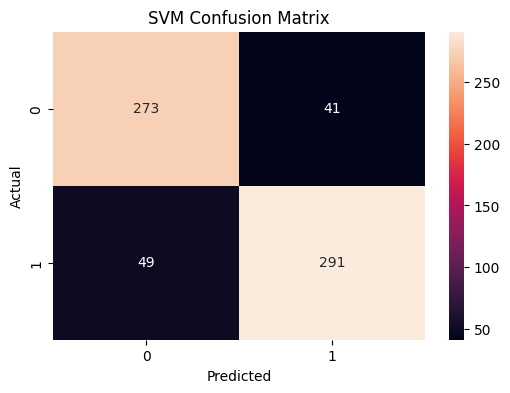

In [ ]:
cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt='d')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()